# Recidivism Model

Predicts the **actual** recidivism outcome (`is_recid`) rather than the COMPAS
`decile_score`. A `RandomForestClassifier` is trained, then we measure the
**false positive rate (FPR) per race** — i.e. how often the model labels someone
a future recidivist when they did **not** actually reoffend.

This is the key fairness lens: a model that wrongly flags one racial group more
often mirrors exactly the disparity ProPublica reported for COMPAS itself.

# 0) Environment

### Imports and Constants

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

DATA_PATH = '../../data/compas_preprocessed.csv'
_RS = 42
_TARGET = 'is_recid'
# decile_score is COMPAS's own prediction, not a defendant feature -> excluded.
_DROP_FEATURES = ['decile_score']
_TEST_PERCENTAGE = 0.2

# Force parallelism in GridSearch
from functools import partial
GridSearchCV = partial(GridSearchCV, n_jobs=-1)

### Import data and isolate target

In [2]:
df = pd.read_csv(DATA_PATH)

y = df.pop(_TARGET)
X = df.drop(columns=_DROP_FEATURES)

print(f'Dataset: {X.shape[0]} rows, {X.shape[1]} features')
print('Target balance (is_recid):')
print(y.value_counts(normalize=True).round(3).to_dict())

Dataset: 6172 rows, 21 features
Target balance (is_recid):
{0: 0.516, 1: 0.484}


### Helper functions

In [3]:
def get_classification_metrics(model, X_test, y_test, X_train, y_train):
    """Accuracy (train/test), precision, recall and F1 for the positive class."""
    y_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    return acc, prec, rec, f1, train_acc

def print_classification_metrics(acc, prec, rec, f1, train_acc):
    print(f'\nTraining Accuracy: {train_acc:.4f}')
    print(f'Test Accuracy:     {acc:.4f}')
    print(f'Difference:        {train_acc - acc:.4f}')
    print()
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1:        {f1:.4f}')

# 1) Train and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=_RS, test_size=_TEST_PERCENTAGE,
    stratify=y,  # keep the recid/no-recid balance in both splits
)

# 2) Random Forest Classifier

We keep a single non-linear model (Random Forest) for the recidivism task. The
hyper-parameter grid mirrors the decile-score notebooks (`n_estimators`,
`max_depth`, `min_samples_leaf`); only the estimator (classifier) and the
GridSearch scoring (`f1`) change.

##### Model pipeline

In [5]:
model_random_forest_pipeline = make_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',   # random subset of features
        random_state=_RS,
    ),
)

##### Hyper parameter optimization

In [6]:
param_grid_random_forest = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_depth': [3, 6, 9],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
}

model_random_forest = GridSearchCV(
    estimator=model_random_forest_pipeline,
    param_grid=param_grid_random_forest,
    cv=5,
    scoring='f1',
    refit=True,
)

model_random_forest.fit(X_train, y_train)

print(f'Best Params: {model_random_forest.best_params_}')

Best Params: {'randomforestclassifier__max_depth': 9, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__n_estimators': 100}


##### Metrics

In [7]:
metrics_random_forest = get_classification_metrics(
    model_random_forest, X_test, y_test, X_train, y_train)
print_classification_metrics(*metrics_random_forest)

print()
print(classification_report(y_test, model_random_forest.predict(X_test),
                            target_names=['no recid', 'recid'], zero_division=0))


Training Accuracy: 0.7620
Test Accuracy:     0.7190
Difference:        0.0430

Precision: 0.7221
Recall:    0.6823
F1:        0.7016

              precision    recall  f1-score   support

    no recid       0.72      0.75      0.73       637
       recid       0.72      0.68      0.70       598

    accuracy                           0.72      1235
   macro avg       0.72      0.72      0.72      1235
weighted avg       0.72      0.72      0.72      1235



##### Confusion Matrix

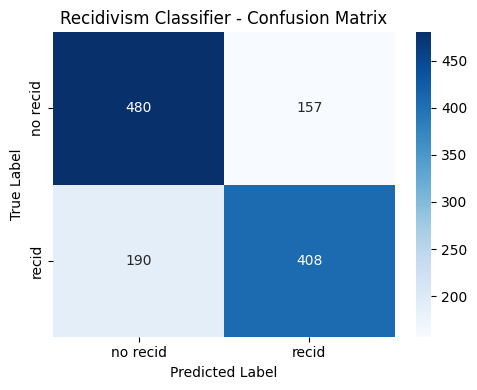

In [8]:
cm = confusion_matrix(y_test, model_random_forest.predict(X_test))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no recid', 'recid'],
            yticklabels=['no recid', 'recid'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Recidivism Classifier - Confusion Matrix')
plt.tight_layout()
plt.show()

# 3) Racial Bias Analysis

Having trained a model on the **real** recidivism outcome, we examine whether its
errors fall unevenly across racial groups.

The headline metric is the **false positive rate (FPR)**: among defendants who did
**not** reoffend (`is_recid == 0`), the fraction the model wrongly predicted as
recidivists. A higher FPR for a group means that group is more often unfairly
flagged -- the same disparity ProPublica found in COMPAS.

### Feature Importance (Random Forest)

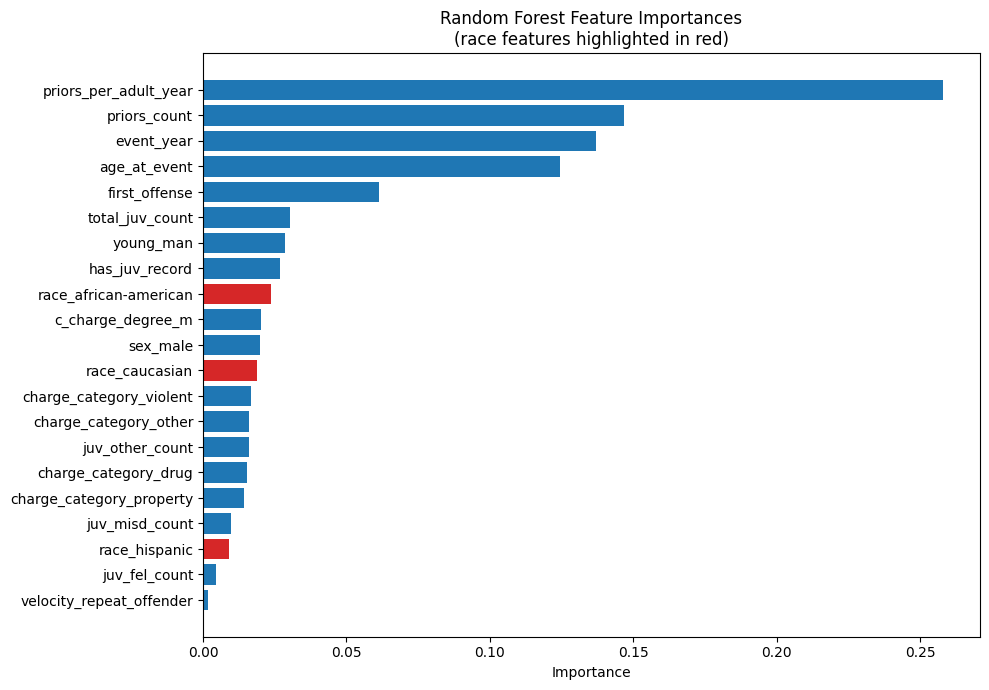

Race feature rankings:
  race_african-american: rank #9 of 21 (0.0236)
  race_caucasian: rank #12 of 21 (0.0188)
  race_hispanic: rank #19 of 21 (0.0092)


In [9]:
rf_estimator = model_random_forest.best_estimator_['randomforestclassifier']
feature_names = X.columns.tolist()
importances = rf_estimator.feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).reset_index(drop=True)

race_cols = {'race_caucasian', 'race_hispanic', 'race_african-american'}
colors = ['#d62728' if f in race_cols else '#1f77b4' for f in importance_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importances\n(race features highlighted in red)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Race feature rankings:')
for _, row in importance_df[importance_df['feature'].isin(race_cols)].iterrows():
    rank = importance_df.index[importance_df['feature'] == row['feature']].item() + 1
    print(f"  {row['feature']}: rank #{rank} of {len(feature_names)} ({row['importance']:.4f})")

### False Positive Rate by Race

We decode the one-hot race columns back into a single label and, per group, compute:

- **base_rate_recid** -- share who actually reoffended
- **fpr** -- of those who did **not** reoffend, share wrongly flagged as recidivist
- **fnr** -- of those who did reoffend, share the model missed

In [10]:
def decode_race(row):
    if row['race_african-american'] == 1:
        return 'african-american'
    elif row['race_caucasian'] == 1:
        return 'caucasian'
    elif row['race_hispanic'] == 1:
        return 'hispanic'
    else:
        return 'other'  # reference category (dropped during encoding)

analysis_df = X_test.copy()
analysis_df['race'] = analysis_df.apply(decode_race, axis=1)
analysis_df['y_true'] = y_test.values
analysis_df['y_pred'] = model_random_forest.predict(X_test)

rows = []
for race, g in analysis_df.groupby('race'):
    neg = g[g['y_true'] == 0]   # did NOT reoffend
    pos = g[g['y_true'] == 1]   # did reoffend
    fpr = (neg['y_pred'] == 1).mean() if len(neg) else np.nan
    fnr = (pos['y_pred'] == 0).mean() if len(pos) else np.nan
    rows.append({
        'race': race,
        'n': len(g),
        'base_rate_recid': round(g['y_true'].mean(), 3),
        'fpr': round(fpr, 4),
        'fnr': round(fnr, 4),
    })

race_metrics = pd.DataFrame(rows)
display(race_metrics)

,race,n,base_rate_recid,fpr,fnr
0,african-american,606,0.558,0.3582,0.2308
1,caucasian,446,0.428,0.1569,0.4293
2,hispanic,100,0.410,0.2881,0.4146
3,other,83,0.337,0.0727,0.4643


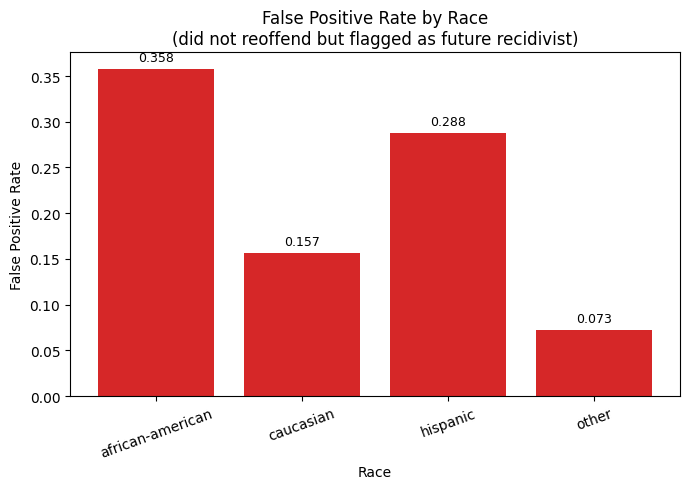

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(race_metrics['race'], race_metrics['fpr'], color='#d62728')
ax.set_title('False Positive Rate by Race\n(did not reoffend but flagged as future recidivist)')
ax.set_ylabel('False Positive Rate')
ax.set_xlabel('Race')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(race_metrics['fpr']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 4) Save Model

In [ ]:
MODELS_DIR = '../../models/recid/w_race'
os.makedirs(MODELS_DIR, exist_ok=True)

path = os.path.join(MODELS_DIR, 'random_forest.joblib')
joblib.dump(model_random_forest, path)
print(f'Saved: {path}')

Saved: ../../models/recid/random_forest.joblib
